# 03 BMRA

Run BMRA based on global responses derived from the pathway activity predictions.

In [1]:
import pandas as pd
import numpy as np
import os
import bmra

In [2]:
cell_line = 'BC3C_dec'

data_dir =f'/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_bmra/blca_publication_OUTPUT_bmra_{cell_line}/'
data_dir_1 = os.path.join(data_dir, f'00_outputs_2020_{cell_line}/')
data_dir_2 = os.path.join(data_dir, f'01_outputs_2020_{cell_line}/')

info_dir =f"/home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_{cell_line}/"

out_dir = os.path.join(data_dir,f'02_outputs_2020_{cell_line}/')


os.makedirs(out_dir, exist_ok = True)

## Load data

### Global responses

Assembled from global responses calculated from predicted pathway activities, and DPD global responses.

In [3]:
def assemble_R_global(pathway_rglobal_file, dpd_rglobal_file):
    """
    Assemble full R_global matrix
    """
    R_global_modules_df = pd.read_csv(pathway_rglobal_file, index_col = 0)

    perts = R_global_modules_df.columns.tolist()

    R_global_DPD_df = pd.read_csv(dpd_rglobal_file, index_col=0).T

    # filter by perts list
    R_global_DPD_df = R_global_DPD_df[R_global_DPD_df.index.isin(perts)]

    # sort by perts list
    R_global_DPD_df["sort_col"] = R_global_DPD_df.index.map({val: i for i, val in enumerate(perts)})
    R_global_DPD_df = R_global_DPD_df.sort_values("sort_col")
    R_global_DPD_df = R_global_DPD_df.drop("sort_col", axis = 1)

    # transpose
    R_global_DPD_df = R_global_DPD_df.T

    R_global_df = pd.concat([R_global_modules_df, R_global_DPD_df])

    return R_global_df

In [4]:
R_global_df = assemble_R_global(
    pathway_rglobal_file = os.path.join(data_dir_2, "R_global_annotated.csv"),
    dpd_rglobal_file = os.path.join(data_dir_1, "R_global_DPDonly_annotated.csv"),
)

modules = R_global_df.index.tolist()
exp_ids = R_global_df.columns.tolist()

R_global = R_global_df.values
n_modules = R_global.shape[0]

print(R_global.shape)
display(R_global_df)

(13, 106)


,ASG002_BC3C_24H:A10,ASG002_BC3C_24H:A11,ASG002_BC3C_24H:A19,ASG002_BC3C_24H:A20,ASG002_BC3C_24H:A21,ASG002_BC3C_24H:B10,ASG002_BC3C_24H:B11,ASG002_BC3C_24H:B14,ASG002_BC3C_24H:B15,ASG002_BC3C_24H:C13,...,SMAD_V11,SMAD_V12,SMAD_V13,SMAD_V14,SMAD_V15,SMAD_V16,SMAD_V17,SMAD_V18,SMAD_V19,SMAD_V20
CDK1_2,-0.725927,-0.564009,0.047524,0.019913,0.072178,-0.259043,-0.071499,-0.424425,0.165125,-0.000459,...,-0.393985,-0.371891,-0.341944,-0.356623,-0.331340,-0.345483,-0.338835,-0.367514,-0.368467,-0.394076
CDK4_6,0.002896,-0.091429,-0.281690,-0.120567,0.026570,-0.109713,-0.094223,-0.044113,-0.256223,0.009709,...,0.242080,0.236977,0.207375,0.187028,0.171922,0.183000,0.211703,0.201469,0.236775,0.205842
EGFR,0.603376,0.511854,0.220740,0.379748,0.549793,0.125318,-0.444233,0.260758,0.282821,-0.032046,...,-1.337895,-0.873447,-0.862535,-0.742792,-0.714415,-0.730224,-0.788083,-0.962928,-0.939542,-0.995467
Estrogen,-0.190528,-0.296460,-0.286513,-0.500914,-0.993401,-0.324503,-0.089841,-0.358440,-0.238489,-0.054942,...,-0.290601,-0.266116,-0.240538,-0.266763,-0.251203,-0.257631,-0.230824,-0.277367,-0.258756,-0.303537
FGFR,-0.086421,-0.196211,-0.088845,0.073912,-0.030853,-0.403438,-0.038446,-0.116167,-0.081176,-0.272415,...,-0.878591,-0.726388,-0.666763,-0.668465,-0.599572,-0.646116,-0.655558,-0.735309,-0.748032,-0.809770
PI3K,-1.949389,-1.864289,-1.688814,-1.423222,-0.626996,-0.172363,-0.007990,-0.484642,-1.366946,-0.237184,...,-0.133134,-0.077357,-0.032891,-0.067821,-0.042575,-0.084217,-0.056306,-0.086221,-0.087914,-0.166357
p53,-0.268405,-0.335504,-0.084758,-0.341971,0.027870,-1.804160,-1.719369,-0.118500,-0.069430,-1.550442,...,0.055674,0.034615,0.047148,0.050473,0.023246,0.050351,0.071810,0.032452,0.073348,0.038895
TOP2A,-0.292334,0.071032,-0.204818,-0.183952,-0.131057,0.019847,0.014272,-1.996041,-0.250612,-0.389249,...,0.153356,0.143011,0.134278,0.112982,0.101772,0.129644,0.139788,0.127097,0.151693,0.145251
Src,-1.048109,-1.975944,0.582887,-1.505108,0.614979,-1.361881,0.536779,0.461964,0.459929,0.499181,...,-0.099676,-0.130252,-0.076174,-0.105480,-0.036400,-0.096381,-0.076959,-0.089895,-0.130951,-0.140445
SMAD3,0.004880,-0.157940,0.044206,-0.403893,0.062953,0.085535,0.034814,0.172621,0.172566,0.059443,...,-1.379033,-1.228732,-1.156666,-1.215547,-1.149276,-1.171335,-1.142202,-1.264666,-1.236815,-1.343690


In [5]:
print(R_global_df.values.min())
print(R_global_df.values.max())

-1.9993441094813444
1.266216428290639


### Perturbation matrix

In [6]:
inhib_conc_df = pd.read_csv(os.path.join(data_dir_1, "inhib_conc_annotated.csv"), index_col = 0)
#LFC_PLCg = pd.read_csv(os.path.join(info_dir,"PLCg_Data_log_2020.csv"),index_col=0)
#inhib_conc = inhib_conc_df.drop(columns=LFC_PLCg.index).values
inhib_conc = inhib_conc_df.values

n_DPDs = R_global.shape[0] - inhib_conc.shape[0]

pert_modules = np.where(inhib_conc != 0, 1, 0)
pert_DPD = np.zeros((n_DPDs, len(exp_ids)))

pert = np.vstack([pert_modules, pert_DPD])

print(pert.shape)
print(pert)

(13, 106)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


### Networks

In [7]:
# empty prior
#G_prior = np.zeros((n_modules, n_modules))
G_prior_df = pd.read_excel('//home/jing/Phd_project/project_UCD_blca/blca_publication_OUTPUT/blca_publication_OUTPUT_LINCS/00_outputs_2020_BC3C_dec/ALL_DATA_2020_post.xlsx',sheet_name = "prior_net_work" , index_col = 0)

G_prior = G_prior_df.values
G_prior_df

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0,0,0,0,0,0,0,0,0,0,0,0,0
CDK4_6,0,0,0,0,0,0,0,0,0,0,0,0,0
EGFR,0,0,0,0,0,0,0,0,0,0,0,0,0
Estrogen,0,0,0,0,0,0,0,0,0,0,0,0,0
FGFR,0,0,0,0,0,0,0,0,0,0,0,0,0
PI3K,0,0,0,0,0,0,0,0,0,0,0,0,0
p53,0,0,0,0,0,0,0,0,0,0,0,0,0
TOP2A,0,0,0,0,0,0,0,0,0,0,0,0,0
Src,0,0,0,0,0,0,0,0,0,0,0,0,0
SMAD3,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
#G_prior_r_df = pd.read_excel(os.path.join(info_dir, "ALL_DATA_2020.xlsx"), sheet_name = "prior_r", index_col = 0)

#G_prior_r = G_prior_r_df.values
#G_prior_r_df

In [9]:
G_not = np.eye(n_modules)
G_not[:, n_modules - n_DPDs :] = 1

G_not

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1.]])

## Run BMRA

In [10]:
n_gibbs = 200_000
n_window = 5_000

mode = "all"
n_iterations = 1

In [11]:
A_mean, A_sd, r_mean, r_sd = bmra.run_bmra(R_global,
            pert,
            G_prior,
            G_not,
            #r_prior = G_prior_r,
            n_gibbs = n_gibbs,
            n_window = n_window,
            mode = mode,
            n_iterations = n_iterations,
        )

A_mean_df = pd.DataFrame(A_mean, index = modules, columns = modules)
A_sd_df = pd.DataFrame(A_sd, index = modules, columns = modules)
r_mean_df = pd.DataFrame(r_mean, index = modules, columns = modules)
r_sd_df = pd.DataFrame(r_sd, index = modules, columns = modules)

display(A_mean_df)
display(A_sd_df)
display(r_mean_df)
display(r_sd_df)

A_mean_df.to_csv(os.path.join(out_dir, "A_mean.csv"))
A_sd_df.to_csv(os.path.join(out_dir, "A_sd.csv"))
r_mean_df.to_csv(os.path.join(out_dir, "r_mean.csv"))
r_sd_df.to_csv(os.path.join(out_dir, "r_sd.csv"))

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.0,0.000166,1.00000,0.000000,1.0,1.000000,0.000000,0.000000,0.261023,0.000000,0.0,0.0,0.0
CDK4_6,0.0,0.000000,0.00000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.000000,0.0,0.0,0.0
EGFR,0.0,0.000000,0.00000,0.000000,1.0,1.000000,0.000175,0.000000,0.377026,1.000000,0.0,0.0,0.0
Estrogen,0.0,0.011504,0.00000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0
FGFR,0.0,0.000000,1.00000,0.000000,0.0,1.000000,0.168741,0.000000,0.000000,1.000000,0.0,0.0,0.0
PI3K,1.0,0.000000,0.65728,1.000000,0.0,0.000000,0.004104,1.000000,0.988654,0.023289,0.0,0.0,0.0
p53,0.0,0.000000,1.00000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.140070,0.0,0.0,0.0
TOP2A,0.0,0.000000,1.00000,0.000000,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.0,0.000000,0.00000,1.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.0,0.000000,1.00000,0.000000,0.0,0.141314,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000e+00,0.012877,4.440892e-16,0.000000e+00,4.440892e-16,4.440892e-16,0.000000e+00,0.000000e+00,4.391927e-01,0.000000e+00,0.0,0.0,0.0
CDK4_6,0.000000e+00,0.000000,0.000000e+00,1.110223e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.110223e-15,0.0,0.0,0.0
EGFR,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,3.552714e-15,3.552714e-15,1.321587e-02,0.000000e+00,4.846416e-01,3.552714e-15,0.0,0.0,0.0
Estrogen,0.000000e+00,0.106637,0.000000e+00,0.000000e+00,8.881784e-16,8.881784e-16,0.000000e+00,0.000000e+00,8.881784e-16,0.000000e+00,0.0,0.0,0.0
FGFR,0.000000e+00,0.000000,1.776357e-15,0.000000e+00,0.000000e+00,1.776357e-15,3.745227e-01,0.000000e+00,0.000000e+00,1.776357e-15,0.0,0.0,0.0
PI3K,3.330669e-15,0.000000,4.746190e-01,3.330669e-15,0.000000e+00,0.000000e+00,6.392714e-02,3.330669e-15,1.059116e-01,1.508187e-01,0.0,0.0,0.0
p53,0.000000e+00,0.000000,1.110223e-15,0.000000e+00,0.000000e+00,1.110223e-15,0.000000e+00,0.000000e+00,0.000000e+00,3.470597e-01,0.0,0.0,0.0
TOP2A,0.000000e+00,0.000000,3.108624e-15,0.000000e+00,0.000000e+00,3.108624e-15,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
Src,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,0.0,0.0
SMAD3,0.000000e+00,0.000000,1.110223e-16,0.000000e+00,0.000000e+00,3.483454e-01,0.000000e+00,0.000000e+00,1.110223e-16,0.000000e+00,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000,0.000013,0.171412,0.000000,0.214685,0.159710,0.000000,0.000000,0.015157,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,0.000000,0.150215,0.000000,0.000000,0.000000,0.000000,0.000000,-0.156308,0.0,0.0,0.0
EGFR,0.000000,0.000000,0.000000,0.000000,0.225300,-0.235549,0.000007,0.000000,-0.030099,0.527084,0.0,0.0,0.0
Estrogen,0.000000,0.002067,0.000000,0.000000,0.260302,0.222682,0.000000,0.000000,0.076446,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.321871,0.000000,0.000000,0.159415,0.017344,0.000000,0.000000,0.229914,0.0,0.0,0.0
PI3K,0.330287,0.000000,-0.097178,0.342965,0.000000,0.000000,0.000299,0.557426,-0.127863,0.003527,0.0,0.0,0.0
p53,0.000000,0.000000,0.144391,0.000000,0.000000,0.208128,0.000000,0.000000,0.000000,-0.026040,0.0,0.0,0.0
TOP2A,0.000000,0.000000,-0.150374,0.000000,0.000000,0.205519,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.000000,0.000000,0.566242,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.321926,0.000000,0.000000,0.011685,0.000000,0.000000,0.099237,0.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000,0.001038,0.023011,0.000000,0.030088,0.020200,0.000000,0.000000,0.027267,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,0.000000,0.000000,0.007424,0.000000,0.000000,0.000000,0.000000,0.000000,0.005585,0.0,0.0,0.0
EGFR,0.000000,0.000000,0.000000,0.000000,0.039144,0.019493,0.000520,0.000000,0.041342,0.030833,0.0,0.0,0.0
Estrogen,0.000000,0.019488,0.000000,0.000000,0.030925,0.023680,0.000000,0.000000,0.020766,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.000000,0.028150,0.000000,0.000000,0.020742,0.039925,0.000000,0.000000,0.030073,0.0,0.0,0.0
PI3K,0.058665,0.000000,0.078429,0.057769,0.000000,0.000000,0.004975,0.072490,0.033810,0.023961,0.0,0.0,0.0
p53,0.000000,0.000000,0.055076,0.000000,0.000000,0.031758,0.000000,0.000000,0.000000,0.067323,0.0,0.0,0.0
TOP2A,0.000000,0.000000,0.006839,0.000000,0.000000,0.007846,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.000000,0.000000,0.005262,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.000000,0.019623,0.000000,0.000000,0.029848,0.000000,0.000000,0.010726,0.000000,0.0,0.0,0.0


In [12]:
np.fill_diagonal(r_mean_df.values,-1)
rm_minus_inv = pd.DataFrame(np.linalg.pinv(r_mean_df),index=r_mean_df.index,columns=r_mean_df.columns)*(-1)
rm_minus_inv.to_csv(os.path.join(out_dir, 'r_minv.csv'))
display(rm_minus_inv)

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,1.060302,0.000159,0.333260,0.069911,0.320913,0.182575,0.005623,0.101772,0.012840,0.249911,2.498002e-16,4.857226e-16,1.110223e-16
CDK4_6,0.021104,1.000343,-0.052935,0.165941,0.035799,0.063897,0.000640,0.035618,-0.011020,-0.175824,-1.029992e-16,3.504141e-16,-5.052382e-16
EGFR,-0.115315,-0.000163,1.384124,-0.078081,0.266762,-0.349136,0.004532,-0.194618,0.073617,0.789557,8.881784e-16,2.164935e-15,2.151057e-15
Estrogen,0.114054,0.002380,0.116612,1.150603,0.350263,0.345317,0.006179,0.192489,0.056184,0.142679,8.049117e-16,1.290634e-15,6.938894e-17
FGFR,0.030755,0.000102,0.532649,0.049000,1.139363,0.093116,0.019793,0.051905,0.030110,0.542503,-1.401657e-15,-2.775558e-16,4.302114e-16
PI3K,0.453864,0.000820,-0.121144,0.393829,0.172659,1.374151,0.003404,0.765988,-0.137009,-0.019526,5.273559e-16,-6.245005e-16,-1.817990e-15
p53,0.078473,0.000145,0.162905,0.069544,0.071652,0.237590,1.001315,0.132439,-0.021127,0.077080,-8.673617e-18,-4.787837e-16,-1.249001e-16
TOP2A,0.110618,0.000193,-0.233034,0.092681,-0.004629,0.334916,0.000018,1.186691,-0.039228,-0.122742,3.226586e-16,-6.036838e-16,-1.634110e-15
Src,0.064582,0.001348,0.066030,0.651520,0.198334,0.195533,0.003499,0.108995,1.031814,0.080791,-6.591949e-16,-4.857226e-16,-3.747003e-16
SMAD3,-0.025411,0.000091,0.450722,0.044120,0.107577,-0.076935,0.001846,-0.042886,0.124493,1.261968,2.359224e-16,1.026956e-15,1.443290e-15


In [13]:
con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in r_mean_df.index:
    for con_from in r_mean_df.columns:
        if ((r_mean_df.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,r_mean_df.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net.txt'),sep='\t',index=False)
display(con_mat)

,From,To,Strength
0,CDK4_6,CDK1_2,0.000013
1,EGFR,CDK1_2,0.171412
2,FGFR,CDK1_2,0.214685
3,PI3K,CDK1_2,0.159710
4,Src,CDK1_2,0.015157
5,Estrogen,CDK4_6,0.150215
6,SMAD3,CDK4_6,-0.156308
7,FGFR,EGFR,0.225300
8,PI3K,EGFR,-0.235549
9,p53,EGFR,0.000007


In [14]:
# now the same but with filtered matrices
# threshold value
Athr = 0.5

rm_filt = r_mean_df[np.abs(A_mean_df) > Athr].fillna(0).copy()
np.fill_diagonal(rm_filt.values,-1)
rm_filt.to_csv(os.path.join(out_dir, 'r_mean_filt.csv'))
display(rm_filt)

rm_filt_minus_inv = pd.DataFrame(np.linalg.pinv(rm_filt),index=rm_filt.index,columns=rm_filt.columns)*(-1)
rm_filt_minus_inv.to_csv(os.path.join(out_dir, 'r_minv_filt.csv'))
display(rm_minus_inv)

con_mat = pd.DataFrame(columns=['From','To','Strength'])
for con_to in rm_filt.index:
    for con_from in rm_filt.columns:
        if ((rm_filt.loc[con_to,con_from] != 0) & (con_from != con_to)):
            row_df = pd.DataFrame([[con_from,con_to,rm_filt.loc[con_to,con_from]]],columns=['From','To','Strength'])
            if con_mat.empty:
                con_mat = row_df.copy()
            else:
                con_mat = pd.concat([con_mat,row_df],axis=0,ignore_index=True)
            #con_mat = con_mat.append({'From':con_from,'To':con_to,'Strength':r_mean_df.loc[con_to,con_from]},ignore_index=True)
con_mat.to_csv(os.path.join(out_dir, 'r_net_filt.txt'),sep='\t',index=False)
#display(con_mat)


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,-1.000000,0.0,0.171412,0.000000,0.214685,0.159710,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,-1.0,0.000000,0.150215,0.000000,0.000000,0.000000,0.000000,0.000000,-0.156308,0.0,0.0,0.0
EGFR,0.000000,0.0,-1.000000,0.000000,0.225300,-0.235549,0.000000,0.000000,0.000000,0.527084,0.0,0.0,0.0
Estrogen,0.000000,0.0,0.000000,-1.000000,0.260302,0.222682,0.000000,0.000000,0.076446,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.0,0.321871,0.000000,-1.000000,0.159415,0.000000,0.000000,0.000000,0.229914,0.0,0.0,0.0
PI3K,0.330287,0.0,-0.097178,0.342965,0.000000,-1.000000,0.000000,0.557426,-0.127863,0.000000,0.0,0.0,0.0
p53,0.000000,0.0,0.144391,0.000000,0.000000,0.208128,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.0,-0.150374,0.000000,0.000000,0.205519,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.0,0.000000,0.566242,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.0,0.321926,0.000000,0.000000,0.000000,0.000000,0.000000,0.099237,-1.000000,0.0,0.0,0.0


,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,1.060302,0.000159,0.333260,0.069911,0.320913,0.182575,0.005623,0.101772,0.012840,0.249911,2.498002e-16,4.857226e-16,1.110223e-16
CDK4_6,0.021104,1.000343,-0.052935,0.165941,0.035799,0.063897,0.000640,0.035618,-0.011020,-0.175824,-1.029992e-16,3.504141e-16,-5.052382e-16
EGFR,-0.115315,-0.000163,1.384124,-0.078081,0.266762,-0.349136,0.004532,-0.194618,0.073617,0.789557,8.881784e-16,2.164935e-15,2.151057e-15
Estrogen,0.114054,0.002380,0.116612,1.150603,0.350263,0.345317,0.006179,0.192489,0.056184,0.142679,8.049117e-16,1.290634e-15,6.938894e-17
FGFR,0.030755,0.000102,0.532649,0.049000,1.139363,0.093116,0.019793,0.051905,0.030110,0.542503,-1.401657e-15,-2.775558e-16,4.302114e-16
PI3K,0.453864,0.000820,-0.121144,0.393829,0.172659,1.374151,0.003404,0.765988,-0.137009,-0.019526,5.273559e-16,-6.245005e-16,-1.817990e-15
p53,0.078473,0.000145,0.162905,0.069544,0.071652,0.237590,1.001315,0.132439,-0.021127,0.077080,-8.673617e-18,-4.787837e-16,-1.249001e-16
TOP2A,0.110618,0.000193,-0.233034,0.092681,-0.004629,0.334916,0.000018,1.186691,-0.039228,-0.122742,3.226586e-16,-6.036838e-16,-1.634110e-15
Src,0.064582,0.001348,0.066030,0.651520,0.198334,0.195533,0.003499,0.108995,1.031814,0.080791,-6.591949e-16,-4.857226e-16,-3.747003e-16
SMAD3,-0.025411,0.000091,0.450722,0.044120,0.107577,-0.076935,0.001846,-0.042886,0.124493,1.261968,2.359224e-16,1.026956e-15,1.443290e-15


In [15]:
# number of zero elements in the matrix
display(len(rm_filt.index)*len(rm_filt.columns) - rm_filt.astype(bool).sum().sum())

120

In [16]:
# number of non-zero elements in the matrix
display(rm_filt.astype(bool).sum().sum() - len(modules))

36

### Visualization

In [17]:
rm_filt_minus_inv

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,1.058170,6.938894e-18,0.332030,0.064390,0.318741,0.176118,-7.632783e-17,0.098173,0.007043,0.248290,2.324529e-16,2.081668e-16,-4.163336e-17
CDK4_6,0.021863,1.000000e+00,-0.053504,0.165376,0.035687,0.066193,1.426810e-16,0.036898,-0.013317,-0.176304,-1.075529e-16,1.977585e-16,-3.400058e-16
EGFR,-0.117110,1.387779e-16,1.387924,-0.053612,0.273602,-0.354570,2.775558e-16,-0.197647,0.120078,0.794457,4.926615e-16,2.775558e-16,2.081668e-16
Estrogen,0.112915,-3.903128e-17,0.115506,1.150226,0.349671,0.341869,1.387779e-16,0.190567,0.058238,0.141275,4.371503e-16,1.942890e-16,2.636780e-16
FGFR,0.027337,1.006140e-16,0.531094,0.055242,1.139904,0.082769,9.783840e-16,0.046138,0.047428,0.542010,5.065393e-16,4.024558e-16,1.387779e-17
PI3K,0.453162,-5.802650e-16,-0.124568,0.386453,0.169817,1.372026,1.769418e-16,0.764803,-0.148530,-0.026615,1.457168e-16,2.775558e-16,3.677614e-16
p53,0.077406,4.033232e-17,0.174478,0.072690,0.074849,0.234360,1.000000e+00,0.130638,-0.013575,0.109173,3.157197e-16,9.714451e-17,1.665335e-16
TOP2A,0.110744,-2.777726e-16,-0.234309,0.087486,-0.006242,0.335296,4.293441e-16,1.186903,-0.048582,-0.124935,-2.142383e-16,-9.367507e-17,-8.847090e-17
Src,0.063937,1.309716e-16,0.065404,0.651307,0.197999,0.193581,1.318390e-16,0.107907,1.032977,0.079996,3.191891e-16,1.387779e-16,2.012279e-16
SMAD3,-0.031356,-9.540979e-17,0.453299,0.047375,0.107728,-0.094935,2.151057e-16,-0.052919,0.141166,1.263695,9.020562e-17,2.081668e-16,1.110223e-16


In [18]:
df_subset=rm_filt_minus_inv[[ 'CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'p53','PI3K',  'TOP2A','Src','SMAD3']]
df_subset = df_subset.loc[['DPD_onc','DPD_risk',	'DPD_immuno_0']]

In [19]:
t_df_subset=df_subset.T
df_subset.reset_index(inplace=True)

Text(0.5, 1.0, 'Predicted global signaling pathway responses of BC3C_dec cell line under conditions ')

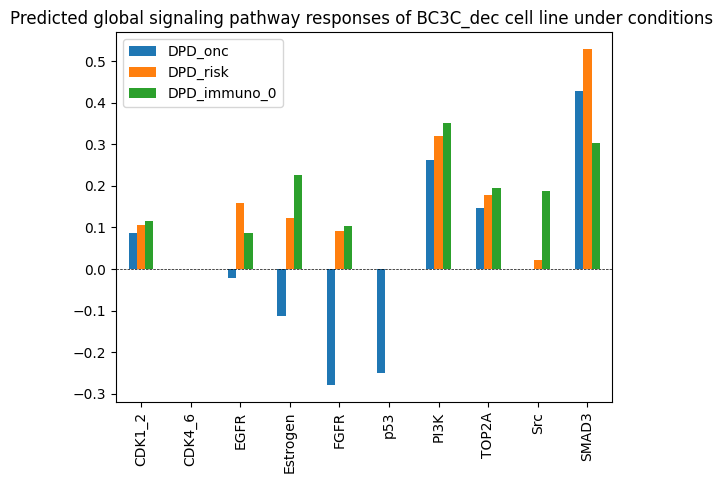

In [20]:
import matplotlib.pyplot as plt
t_df_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted global signaling pathway responses of {cell_line} cell line under conditions ")

In [21]:
display(rm_filt)
rm_subset=rm_filt[['CDK1_2', 'CDK4_6', 'EGFR', 'Estrogen', 'FGFR',
       'PI3K', 'p53', 'TOP2A','Src','SMAD3']]

,CDK1_2,CDK4_6,EGFR,Estrogen,FGFR,PI3K,p53,TOP2A,Src,SMAD3,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,-1.000000,0.0,0.171412,0.000000,0.214685,0.159710,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
CDK4_6,0.000000,-1.0,0.000000,0.150215,0.000000,0.000000,0.000000,0.000000,0.000000,-0.156308,0.0,0.0,0.0
EGFR,0.000000,0.0,-1.000000,0.000000,0.225300,-0.235549,0.000000,0.000000,0.000000,0.527084,0.0,0.0,0.0
Estrogen,0.000000,0.0,0.000000,-1.000000,0.260302,0.222682,0.000000,0.000000,0.076446,0.000000,0.0,0.0,0.0
FGFR,0.000000,0.0,0.321871,0.000000,-1.000000,0.159415,0.000000,0.000000,0.000000,0.229914,0.0,0.0,0.0
PI3K,0.330287,0.0,-0.097178,0.342965,0.000000,-1.000000,0.000000,0.557426,-0.127863,0.000000,0.0,0.0,0.0
p53,0.000000,0.0,0.144391,0.000000,0.000000,0.208128,-1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
TOP2A,0.000000,0.0,-0.150374,0.000000,0.000000,0.205519,0.000000,-1.000000,0.000000,0.000000,0.0,0.0,0.0
Src,0.000000,0.0,0.000000,0.566242,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000,0.0,0.0,0.0
SMAD3,0.000000,0.0,0.321926,0.000000,0.000000,0.000000,0.000000,0.000000,0.099237,-1.000000,0.0,0.0,0.0


In [22]:
rm_subset=rm_subset.loc[['DPD_onc','DPD_risk',	'DPD_immuno_0']]
rm_subset=rm_subset.T
display(rm_subset)

,DPD_onc,DPD_risk,DPD_immuno_0
CDK1_2,0.000000,0.000000,0.000000
CDK4_6,0.000000,0.000000,0.000000
EGFR,0.000000,0.000000,0.000000
Estrogen,-0.203732,0.000000,0.000000
FGFR,-0.263343,0.000000,0.000000
PI3K,0.334839,0.262560,0.245884
p53,-0.250444,0.000000,0.000000
TOP2A,0.000000,0.000000,0.000000
Src,0.000000,0.000000,0.185618
SMAD3,0.502636,0.424302,0.232625


Text(0.5, 1.0, 'Predicted local signaling pathway responses of BC3C_dec cell line under conditions ')

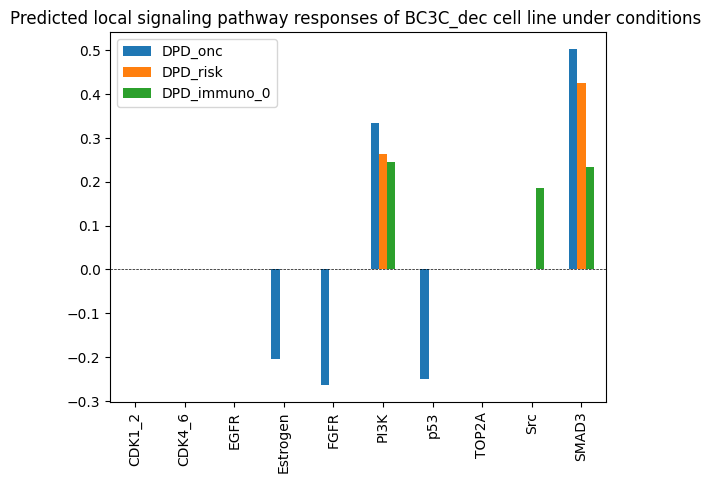

In [23]:
rm_subset.plot.bar()
plt.axhline(y=0, linestyle='--', color='black',linewidth=0.5)
plt.title(f"Predicted local signaling pathway responses of {cell_line} cell line under conditions ")